<a href="https://colab.research.google.com/github/Himanshu0518/Sales-Analytics-Customer-Behavior-Dashboard/blob/main/notebooks/chort-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
order_df=pd.read_csv('/content/Orders.csv', sep=';', on_bad_lines='skip')
order_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Postal Code,Product ID,Sales,Quantity,Discount,Profit
0,1,CA-2022-152156,08/11/2022,11/11/2022,Second Class,CG-12520,Consumer,42420,FUR-BO-10001798,"261,96",2,0,"41,9136"
1,2,CA-2022-152156,08/11/2022,11/11/2022,Second Class,CG-12520,Consumer,42420,FUR-CH-10000454,"731,94",3,0,"219,582"
2,3,CA-2022-138688,12/06/2022,16/06/2022,Second Class,DV-13045,Corporate,90036,OFF-LA-10000240,"14,62",2,0,"6,8714"
3,4,US-2021-108966,11/10/2021,18/10/2021,Standard Class,SO-20335,Consumer,33311,FUR-TA-10000577,"957,5775",5,"0,45","-383,031"
4,5,US-2021-108966,11/10/2021,18/10/2021,Standard Class,SO-20335,Consumer,33311,OFF-ST-10000760,"22,368",2,"0,2","2,5164"


In [ ]:
order_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Row ID       9994 non-null   int64 
 1   Order ID     9994 non-null   object
 2   Order Date   9994 non-null   object
 3   Ship Date    9994 non-null   object
 4   Ship Mode    9994 non-null   object
 5   Customer ID  9994 non-null   object
 6   Segment      9994 non-null   object
 7   Postal Code  9994 non-null   int64 
 8   Product ID   9994 non-null   object
 9   Sales        9994 non-null   object
 10  Quantity     9994 non-null   int64 
 11  Discount     9994 non-null   object
 12  Profit       9994 non-null   object
dtypes: int64(3), object(10)
memory usage: 1015.1+ KB


In [ ]:
# Convert 'Sales' and 'Profit' to numeric, handling comma as decimal separator
order_df['Sales'] = order_df['Sales'].str.replace(',', '.').astype(float)
order_df['Profit'] = order_df['Profit'].str.replace(',', '.').astype(float)

# Convert 'Order Date' and 'Ship Date' to datetime objects
order_df['Order Date'] = pd.to_datetime(order_df['Order Date'], format='%d/%m/%Y')
order_df['Ship Date'] = pd.to_datetime(order_df['Ship Date'], format='%d/%m/%Y')

# Display the DataFrame info to confirm data types
order_df.info()

In [ ]:
order_df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Postal Code,Product ID,Sales,Quantity,Discount,Profit
0,1,CA-2022-152156,2022-11-08,2022-11-11,Second Class,CG-12520,Consumer,42420,FUR-BO-10001798,261.96,2,0,41.9136
1,2,CA-2022-152156,2022-11-08,2022-11-11,Second Class,CG-12520,Consumer,42420,FUR-CH-10000454,731.94,3,0,219.5820


In [ ]:
cust_df=pd.read_csv('/content/Customers.csv')
cust_df.head()

# Cohort Analysis

In [29]:
order_df['cohort'] = order_df.groupby('Customer ID')['Order Date'].transform('min').dt.to_period('Q')
order_df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Postal Code,Product ID,Sales,Quantity,Discount,Profit,year,month,cohort,order_date,cohort_period
0,1,CA-2022-152156,2022-11-08,2022-11-11,Second Class,CG-12520,Consumer,42420,FUR-BO-10001798,261.96,2,0,41.9136,2022,11,2021Q4,2022-11,13
1,2,CA-2022-152156,2022-11-08,2022-11-11,Second Class,CG-12520,Consumer,42420,FUR-CH-10000454,731.94,3,0,219.5820,2022,11,2021Q4,2022-11,13


In [15]:
order_df.shape

(9994, 16)

In [30]:
order_df['order_date']=order_df['Order Date'].dt.to_period('Q')

In [31]:
order_df['cohort_period'] = (order_df['order_date'] - order_df['cohort']).apply(lambda x:x.n)

In [32]:
# Group by Cohort and Cohort_Period to count unique customers
cohort_counts = order_df.groupby(['cohort', 'cohort_period'])['Customer ID'].nunique().reset_index()
cohort_counts = cohort_counts.rename(columns={'Customer ID': 'Customer_Count'})
cohort_counts

,cohort,cohort_period,Customer_Count
0,2020Q1,0,121
1,2020Q1,1,20
2,2020Q1,2,28
3,2020Q1,3,41
4,2020Q1,4,18
...,...,...,...
129,2023Q2,0,2
130,2023Q2,2,1
131,2023Q3,0,3
132,2023Q3,1,1


In [33]:
cohort_pivot = cohort_counts.pivot_table(index='cohort', columns='cohort_period', values='Customer_Count')
display(cohort_pivot.head())

cohort_period,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
cohort,,,,,,,,,,,,,,,,
2020Q1,121.0,20.0,28.0,41.0,18.0,27.0,33.0,45.0,26.0,34.0,43.0,53.0,34.0,49.0,51.0,66.0
2020Q2,160.0,39.0,58.0,28.0,44.0,47.0,68.0,33.0,51.0,57.0,78.0,37.0,58.0,72.0,85.0,NaN
2020Q3,161.0,53.0,30.0,46.0,48.0,67.0,30.0,48.0,64.0,70.0,37.0,63.0,72.0,84.0,NaN,NaN
2020Q4,153.0,27.0,31.0,48.0,61.0,30.0,50.0,58.0,63.0,42.0,56.0,64.0,95.0,NaN,NaN,NaN
2021Q1,32.0,8.0,10.0,8.0,6.0,6.0,12.0,16.0,12.0,12.0,7.0,16.0,NaN,NaN,NaN,NaN


In [34]:
# Calculate retention rate
cohort_sizes = cohort_pivot.iloc[:,0]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0)
display(retention_matrix.head())

cohort_period,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
cohort,,,,,,,,,,,,,,,,
2020Q1,1.0,0.165289,0.231405,0.338843,0.148760,0.223140,0.272727,0.371901,0.214876,0.280992,0.355372,0.438017,0.280992,0.404959,0.421488,0.545455
2020Q2,1.0,0.243750,0.362500,0.175000,0.275000,0.293750,0.425000,0.206250,0.318750,0.356250,0.487500,0.231250,0.362500,0.450000,0.531250,NaN
2020Q3,1.0,0.329193,0.186335,0.285714,0.298137,0.416149,0.186335,0.298137,0.397516,0.434783,0.229814,0.391304,0.447205,0.521739,NaN,NaN
2020Q4,1.0,0.176471,0.202614,0.313725,0.398693,0.196078,0.326797,0.379085,0.411765,0.274510,0.366013,0.418301,0.620915,NaN,NaN,NaN
2021Q1,1.0,0.250000,0.312500,0.250000,0.187500,0.187500,0.375000,0.500000,0.375000,0.375000,0.218750,0.500000,NaN,NaN,NaN,NaN


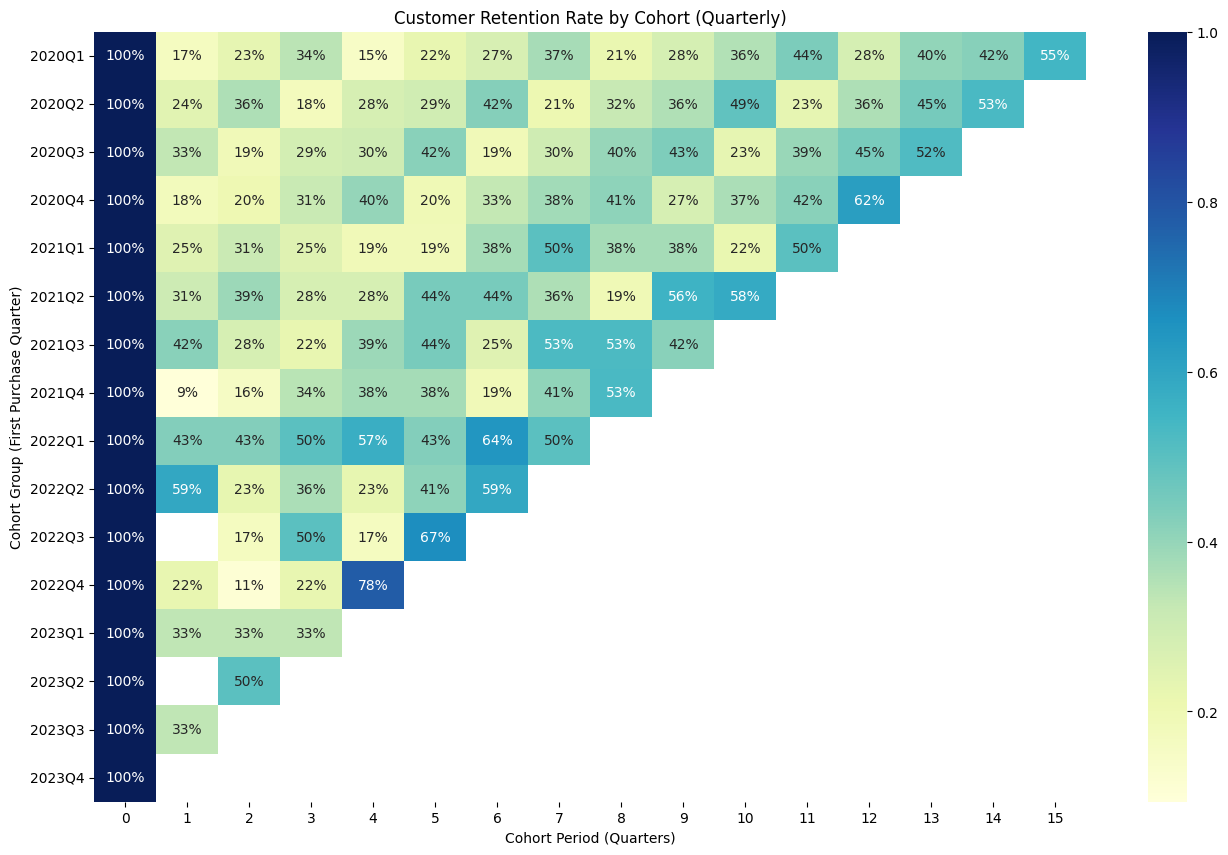

In [35]:
plt.figure(figsize=(16, 10))
sns.heatmap(retention_matrix, annot=True, fmt='.0%', cmap='YlGnBu')
plt.title('Customer Retention Rate by Cohort (Quarterly)')
plt.xlabel('Cohort Period (Quarters)')
plt.ylabel('Cohort Group (First Purchase Quarter)')
plt.show()

### Churn Analysis

Churn rate is often defined as 1 - retention rate. We can calculate this from our `retention_matrix`.

### What is Cohort Analysis?

Cohort analysis is a technique used in analytics to understand the behavior of specific user groups (cohorts) over time. A 'cohort' is a group of users who share a common characteristic over a specified period – in our case, the quarter in which they made their first purchase. By tracking these groups, we can observe how their behavior (like retention or churn) changes from the point they join onwards, rather than just looking at aggregated metrics that might mask underlying trends.

### What is Churn Analysis?

Churn analysis focuses on understanding customer attrition, or 'churn,' which refers to the rate at which customers stop doing business with a company over a given period. In the context of cohort analysis, we calculate the churn rate for each cohort at different points in their lifecycle. A high churn rate indicates that customers are leaving quickly, while a low rate suggests strong customer loyalty. Analyzing churn helps identify areas for improvement in customer experience, product, or service to reduce customer loss.

In [36]:
churn_matrix = 1 - retention_matrix
display(churn_matrix.head())

cohort_period,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
cohort,,,,,,,,,,,,,,,,
2020Q1,0.0,0.834711,0.768595,0.661157,0.851240,0.776860,0.727273,0.628099,0.785124,0.719008,0.644628,0.561983,0.719008,0.595041,0.578512,0.454545
2020Q2,0.0,0.756250,0.637500,0.825000,0.725000,0.706250,0.575000,0.793750,0.681250,0.643750,0.512500,0.768750,0.637500,0.550000,0.468750,NaN
2020Q3,0.0,0.670807,0.813665,0.714286,0.701863,0.583851,0.813665,0.701863,0.602484,0.565217,0.770186,0.608696,0.552795,0.478261,NaN,NaN
2020Q4,0.0,0.823529,0.797386,0.686275,0.601307,0.803922,0.673203,0.620915,0.588235,0.725490,0.633987,0.581699,0.379085,NaN,NaN,NaN
2021Q1,0.0,0.750000,0.687500,0.750000,0.812500,0.812500,0.625000,0.500000,0.625000,0.625000,0.781250,0.500000,NaN,NaN,NaN,NaN


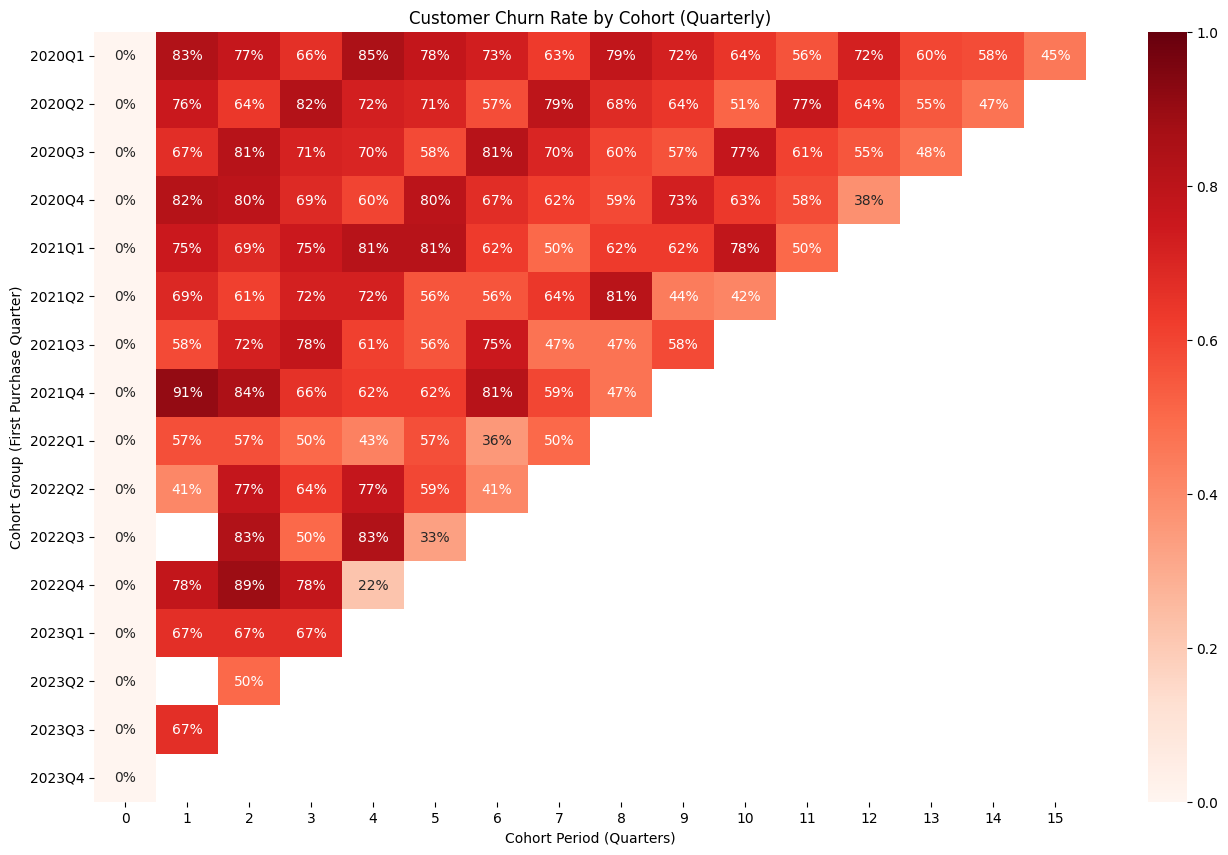

In [37]:
plt.figure(figsize=(16, 10))
sns.heatmap(churn_matrix, annot=True, fmt='.0%', cmap='Reds', vmin=0, vmax=1)
plt.title('Customer Churn Rate by Cohort (Quarterly)')
plt.xlabel('Cohort Period (Quarters)')
plt.ylabel('Cohort Group (First Purchase Quarter)')
plt.show()

### Average Retention and Churn Rates Over Time

Let's look at the average retention and churn rates across all cohorts for each cohort period to get an overall picture of how customer loyalty and attrition evolve.

In [38]:
avg_retention = retention_matrix.mean(axis=0)
print('Average Retention Rate per Cohort Period:')
display(avg_retention)

Average Retention Rate per Cohort Period:


,0
cohort_period,
0,1.000000
1,0.299157
2,0.277516
3,0.317402
4,0.341075
5,0.371349
6,0.370157
7,0.394501
8,0.371422


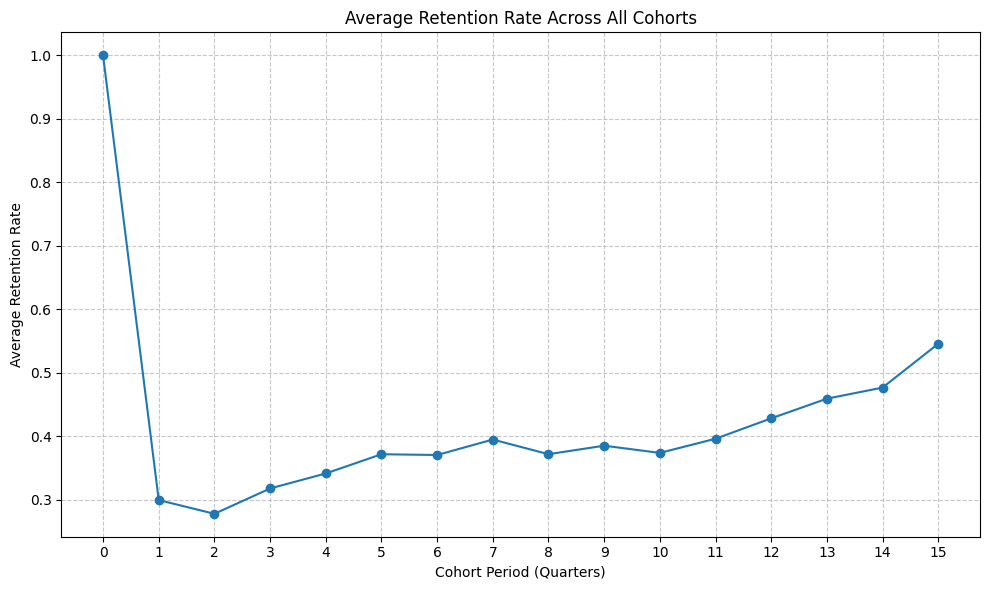

In [39]:
plt.figure(figsize=(10, 6))
avg_retention.plot(kind='line', marker='o')
plt.title('Average Retention Rate Across All Cohorts')
plt.xlabel('Cohort Period (Quarters)')
plt.ylabel('Average Retention Rate')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(avg_retention.index) # Ensure all cohort periods are shown on x-axis
plt.tight_layout()
plt.show()

In [40]:
avg_churn = churn_matrix.mean(axis=0)
print('Average Churn Rate per Cohort Period:')
display(avg_churn)

Average Churn Rate per Cohort Period:


,0
cohort_period,
0,0.000000
1,0.700843
2,0.722484
3,0.682598
4,0.658925
5,0.628651
6,0.629843
7,0.605499
8,0.628578


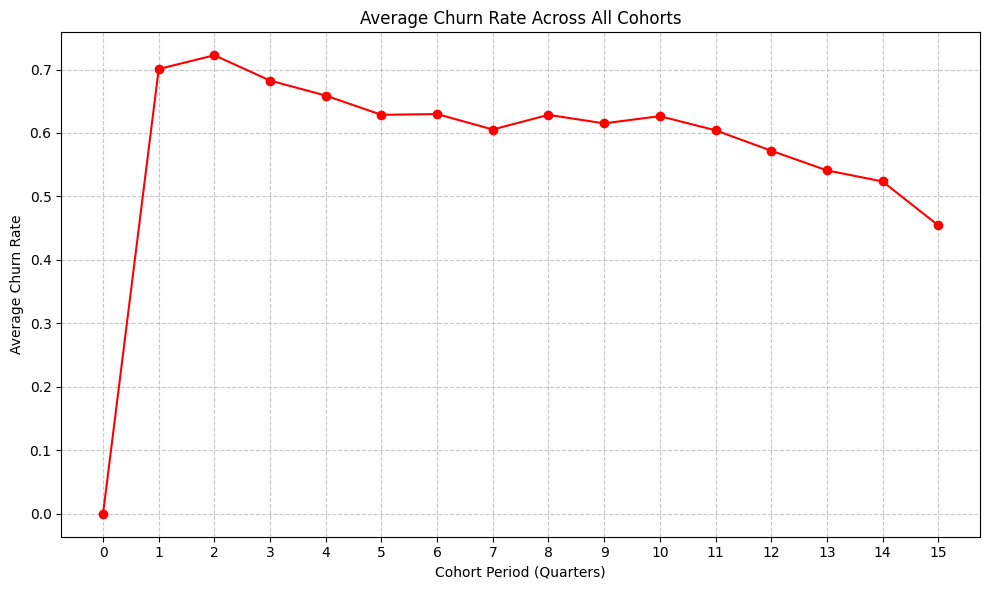

In [41]:
plt.figure(figsize=(10, 6))
avg_churn.plot(kind='line', marker='o', color='red')
plt.title('Average Churn Rate Across All Cohorts')
plt.xlabel('Cohort Period (Quarters)')
plt.ylabel('Average Churn Rate')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(avg_churn.index) # Ensure all cohort periods are shown on x-axis
plt.tight_layout()
plt.show()